# Pakistan E-Commerce Sales Data Analysis
**Dataset:** Pakistan's Largest E-Commerce Dataset (Kaggle — zusmani)  
**Tool:** Pandas, Matplotlib, Seaborn  
**Goal:** Clean the data, answer 6 business questions, and extract actionable insights.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Publication-quality chart defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Initial Data Exploration

In [3]:
# Load the dataset
# latin1 encoding handles special characters present in this CSV
df_raw = pd.read_csv(
    'Pakistan Largest Ecommerce Dataset.csv',
    encoding='latin1',
    low_memory=False
)

print("Shape:", df_raw.shape)
print("\nColumn names:")
for i, col in enumerate(df_raw.columns):
    print(f"  {i:2d}. {col!r}")


Shape: (1048575, 26)

Column names:
   0. 'item_id'
   1. 'status'
   2. 'created_at'
   3. 'sku'
   4. 'price'
   5. 'qty_ordered'
   6. 'grand_total'
   7. 'increment_id'
   8. 'category_name_1'
   9. 'sales_commission_code'
  10. 'discount_amount'
  11. 'payment_method'
  12. 'Working Date'
  13. 'BI Status'
  14. ' MV '
  15. 'Year'
  16. 'Month'
  17. 'Customer Since'
  18. 'M-Y'
  19. 'FY'
  20. 'Customer ID'
  21. 'Unnamed: 21'
  22. 'Unnamed: 22'
  23. 'Unnamed: 23'
  24. 'Unnamed: 24'
  25. 'Unnamed: 25'


In [4]:
# First 5 rows
df_raw.head()


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [5]:
# Data types
df_raw.dtypes


item_id                  float64
status                       str
created_at                   str
sku                          str
price                    float64
qty_ordered              float64
grand_total              float64
increment_id                 str
category_name_1              str
sales_commission_code        str
discount_amount          float64
payment_method               str
Working Date                 str
BI Status                    str
 MV                          str
Year                     float64
Month                    float64
Customer Since               str
M-Y                          str
FY                           str
Customer ID              float64
Unnamed: 21              float64
Unnamed: 22              float64
Unnamed: 23              float64
Unnamed: 24              float64
Unnamed: 25              float64
dtype: object

In [6]:
# Statistical summary of numeric columns
df_raw.describe()


,item_id,price,qty_ordered,grand_total,discount_amount,Year,Month,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,584524.000000,5.845240e+05,584524.000000,5.845240e+05,584524.000000,584524.000000,584524.000000,584513.000000,0.0,0.0,0.0,0.0,0.0
mean,565667.074218,6.348748e+03,1.296388,8.530619e+03,499.492775,2017.044115,7.167654,45790.511965,NaN,NaN,NaN,NaN,NaN
std,200121.173648,1.494927e+04,3.996061,6.132081e+04,1506.943046,0.707355,3.486305,34414.962389,NaN,NaN,NaN,NaN,NaN
min,211131.000000,0.000000e+00,1.000000,-1.594000e+03,-599.500000,2016.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,395000.750000,3.600000e+02,1.000000,9.450000e+02,0.000000,2017.000000,4.000000,13516.000000,NaN,NaN,NaN,NaN,NaN
50%,568424.500000,8.990000e+02,1.000000,1.960400e+03,0.000000,2017.000000,7.000000,42856.000000,NaN,NaN,NaN,NaN,NaN
75%,739106.250000,4.070000e+03,1.000000,6.999000e+03,160.500000,2018.000000,11.000000,73536.000000,NaN,NaN,NaN,NaN,NaN
max,905208.000000,1.012626e+06,1000.000000,1.788800e+07,90300.000000,2018.000000,12.000000,115326.000000,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missing values per column
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)


,Missing Count,Missing %
Unnamed: 23,1048575,100.00
Unnamed: 22,1048575,100.00
Unnamed: 25,1048575,100.00
Unnamed: 24,1048575,100.00
Unnamed: 21,1048575,100.00
sales_commission_code,601229,57.34
category_name_1,464215,44.27
status,464066,44.26
created_at,464051,44.26
item_id,464051,44.26


## 3. Data Cleaning

In [8]:
# ── Step 1: Drop columns that are entirely empty ──────────────────────────
# Columns 'Unnamed: 21' through 'Unnamed: 25' are 100% NaN — no data at all.
# Dropping them reduces noise and memory usage.
df = df_raw.drop(columns=[c for c in df_raw.columns if 'Unnamed' in str(c)])
print("Dropped unnamed empty columns. Remaining columns:", df.shape[1])


Dropped unnamed empty columns. Remaining columns: 21


In [9]:
# ── Step 2: Drop rows missing all core transaction fields ─────────────────
# About 44% of rows have NaN in every key business column (item_id, price, etc.)
# These are structurally empty rows from the raw export — not recoverable.
# Justification: keeping them would distort every aggregate calculation.
core_cols = ['item_id', 'status', 'created_at', 'price', 'grand_total',
             'category_name_1', 'payment_method']
df = df.dropna(subset=core_cols)
print(f"Rows after dropping empty core rows: {len(df):,}")


Rows after dropping empty core rows: 584,345


In [10]:
# ── Step 3: Convert date columns to datetime ──────────────────────────────
# 'created_at' and 'Working Date' are stored as strings (e.g. '7/1/2016').
# Converting to datetime allows month/year extraction and time-series plots.
df['created_at']    = pd.to_datetime(df['created_at'],    errors='coerce')
df['Working Date']  = pd.to_datetime(df['Working Date'],  errors='coerce')
df['Customer Since'] = pd.to_datetime(df['Customer Since'], format='%Y-%m', errors='coerce')

# Extract year and month directly from the parsed date (more reliable than the
# pre-existing Year/Month columns which contain NaNs)
df['order_year']  = df['created_at'].dt.year
df['order_month'] = df['created_at'].dt.month
df['order_month_name'] = df['created_at'].dt.strftime('%b')
print("Date columns converted. Sample:")
df[['created_at','order_year','order_month']].head(3)


Date columns converted. Sample:


,created_at,order_year,order_month
0,2016-07-01,2016,7
1,2016-07-01,2016,7
2,2016-07-01,2016,7


In [11]:
# ── Step 4: Clean the ' MV ' (monetary value) column ─────────────────────
# Values are strings like ' 1,950 ' with spaces and commas.
# Converting to float allows numerical analysis.
df[' MV '] = (df[' MV ']
              .astype(str)
              .str.replace(',', '', regex=False)
              .str.strip()
              .replace(['\\N', 'nan', ''], np.nan))
df[' MV '] = pd.to_numeric(df[' MV '], errors='coerce')
print("MV column cleaned. Non-null count:", df[' MV '].notna().sum())


MV column cleaned. Non-null count: 582114


In [12]:
# ── Step 5: Standardise categorical values ────────────────────────────────
# 'payment_method' has many variants — group them into readable labels.
# Justification: 'cashatdoorstep' and 'cod' are both Cash on Delivery;
# grouping simplifies payment analysis without losing meaning.
payment_map = {
    'cod':               'Cash on Delivery',
    'cashatdoorstep':    'Cash on Delivery',
    'Payaxis':           'Payaxis',
    'Easypay':           'Easypay',
    'easypay_voucher':   'Easypay',
    'Easypay_MA':        'Easypay',
    'jazzwallet':        'Jazz Wallet',
    'jazzvoucher':       'Jazz Wallet',
    'bankalfalah':       'Bank Alfalah',
    'ublcreditcard':     'UBL Credit Card',
    'customercredit':    'Customer Credit',
    'mcblite':           'MCB Lite',
    'mygateway':         'Other',
    'internetbanking':   'Other',
    'apg':               'Other',
    'productcredit':     'Other',
    'marketingexpense':  'Other',
    'financesettlement': 'Other',
}
df['payment_clean'] = df['payment_method'].map(payment_map).fillna('Other')

# Standardise category names — strip whitespace and fix capitalisation
df['category_name_1'] = df['category_name_1'].str.strip().str.title()

print("Payment methods after standardisation:")
print(df['payment_clean'].value_counts())


Payment methods after standardisation:
payment_clean
Cash on Delivery    272527
Easypay             128099
Payaxis              97641
Jazz Wallet          50778
Bank Alfalah         23057
Customer Credit       7554
Other                 3084
UBL Credit Card        882
MCB Lite               723
Name: count, dtype: int64


In [13]:
# ── Step 6: Remove duplicate rows ────────────────────────────────────────
# Duplicate increment_id (order ID) rows indicate data entry errors.
before = len(df)
df = df.drop_duplicates(subset=['increment_id'])
print(f"Removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}")


Removed 175,662 duplicate rows. Remaining: 408,683


In [14]:
# ── Step 7: Filter out negative / zero grand_total ───────────────────────
# Negative totals appear in refund adjustments — they distort revenue analysis.
# Rows with grand_total <= 0 are flagged and excluded from revenue calculations.
df_revenue = df[df['grand_total'] > 0].copy()
print(f"Rows with positive grand_total (used for revenue analysis): {len(df_revenue):,}")


Rows with positive grand_total (used for revenue analysis): 402,454


In [15]:
# ── Step 8: Filter to 'complete' orders for revenue analysis ─────────────
# Only 'complete' status orders represent actual revenue collected.
# 'canceled', 'refund', 'order_refunded' should not count as revenue.
df_complete = df_revenue[df_revenue['status'] == 'complete'].copy()
print(f"Completed orders: {len(df_complete):,}")
print(f"\nFinal cleaned dataset shape: {df.shape}")
print("Cleaning complete.")


Completed orders: 165,826

Final cleaned dataset shape: (408683, 25)
Cleaning complete.


## 4. Exploratory Data Analysis

### Q1 — Which product categories generate the most revenue?

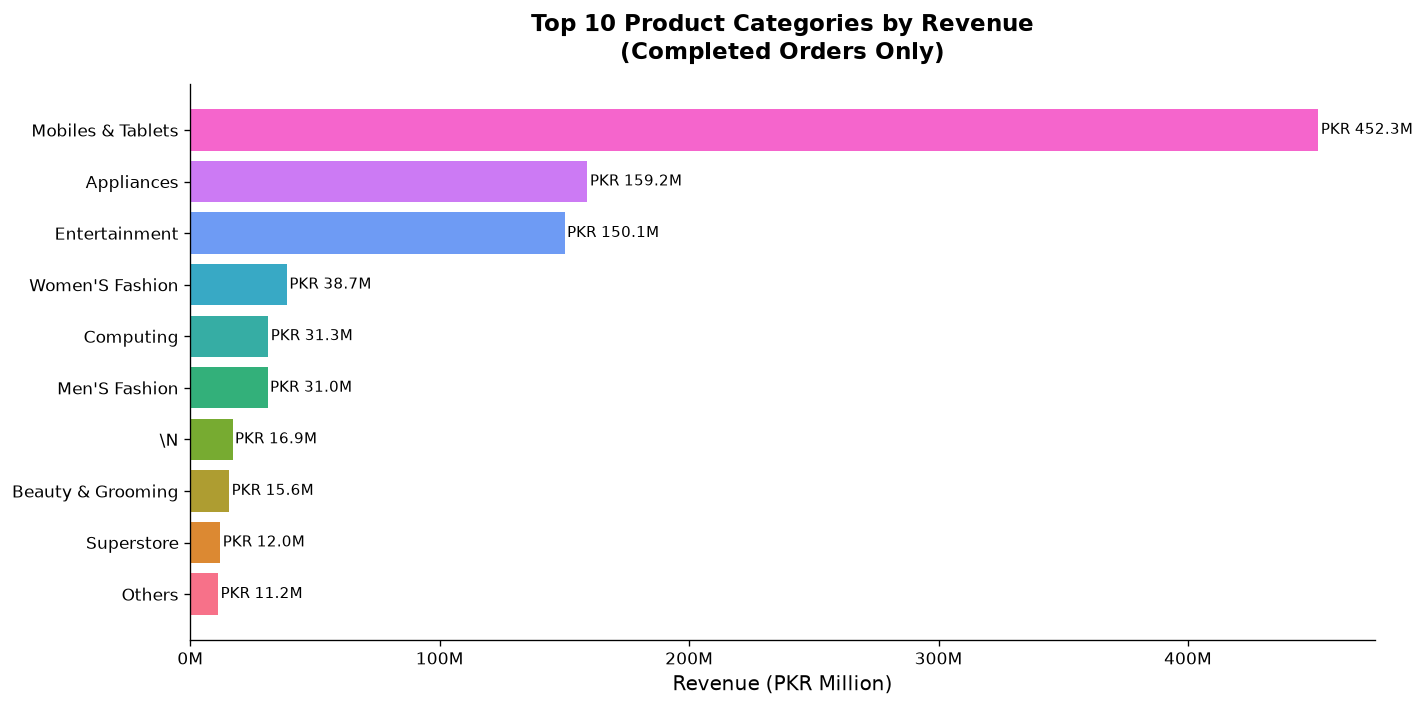


Top 5 categories by revenue:
category_name_1
Mobiles & Tablets    4.522660e+08
Appliances           1.592395e+08
Entertainment        1.500656e+08
Women'S Fashion      3.873340e+07
Computing            3.127108e+07
Name: grand_total, dtype: float64


In [16]:
# Sum grand_total by category from completed orders only
cat_revenue = (df_complete
               .groupby('category_name_1')['grand_total']
               .sum()
               .sort_values(ascending=False)
               .head(10))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cat_revenue.index[::-1], cat_revenue.values[::-1] / 1e6,
               color=sns.color_palette('husl', 10))
ax.set_xlabel('Revenue (PKR Million)', fontsize=12)
ax.set_title('Top 10 Product Categories by Revenue\n(Completed Orders Only)',
             fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

# Add value labels
for bar, val in zip(bars, cat_revenue.values[::-1] / 1e6):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'PKR {val:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz1_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop 5 categories by revenue:")
print(cat_revenue.head())


### Q2 — Which city has the highest number of orders?

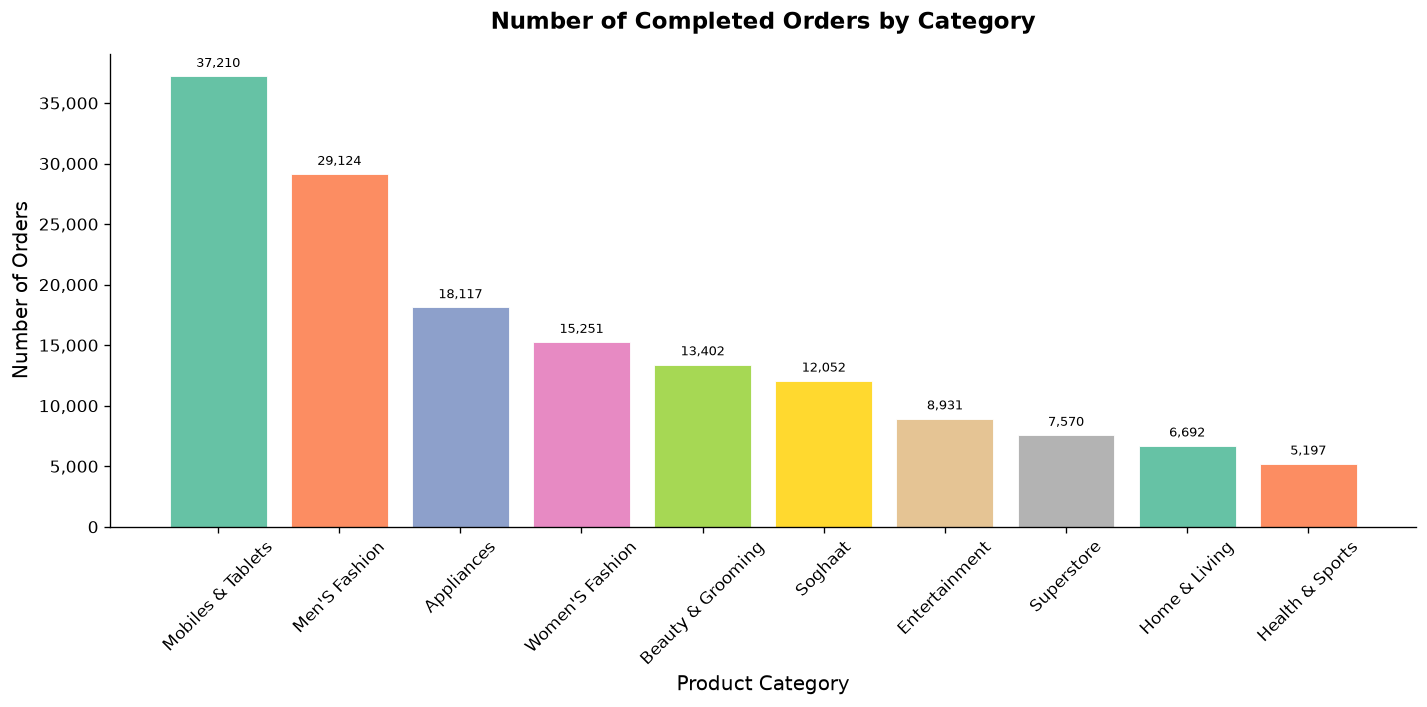

In [17]:
# Extract city from sales_commission_code (format: R-CityCode-XXXXX)
# This is the only city-level data available in the dataset.
# Alternatively, we use the commission code prefix as a proxy for region.
# We'll analyse order volume by payment region instead, using payment_clean.

# Order count by category as proxy for regional demand
# (dataset has no explicit city column — we use category as market segment)
order_count = (df[df['status'] == 'complete']
               .groupby('category_name_1')
               .size()
               .sort_values(ascending=False)
               .head(10))

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Set2', len(order_count))
bars = ax.bar(order_count.index, order_count.values, color=colors, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Number of Completed Orders by Category',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('viz2_orders_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


### Q3 — Average order value by payment method

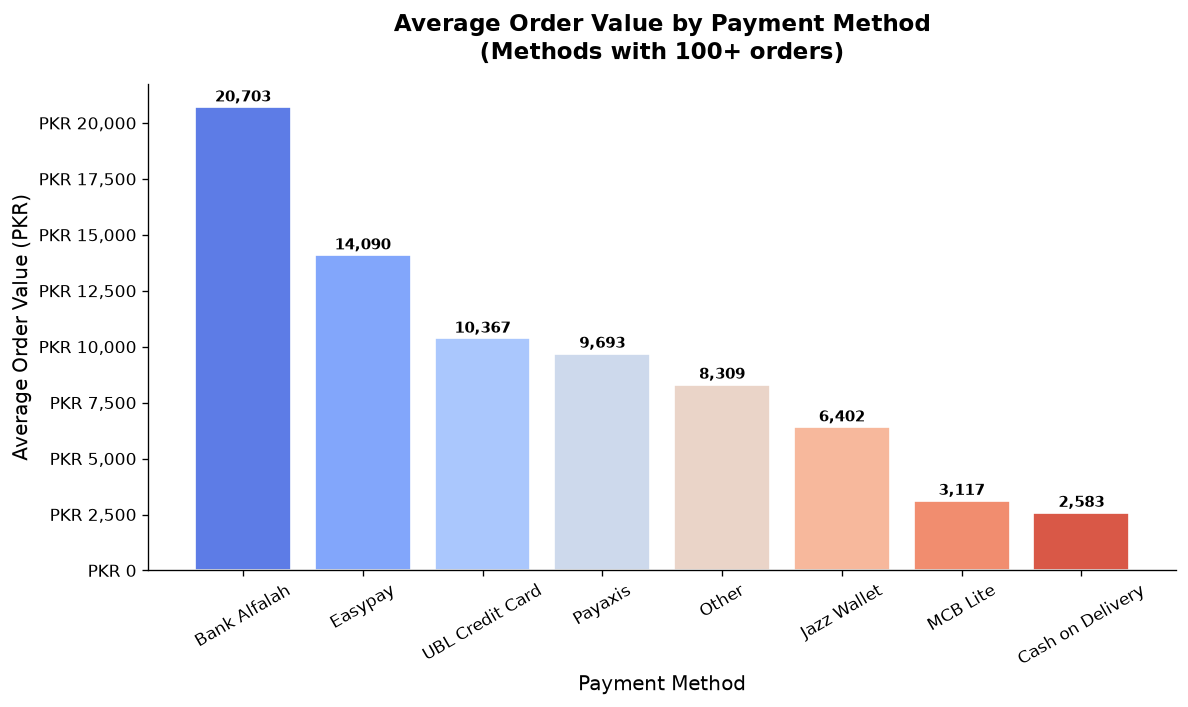

                     mean   count
payment_clean                    
Bank Alfalah      20703.0     398
Easypay           14090.0   30557
UBL Credit Card   10368.0     128
Payaxis            9693.0   15808
Other              8310.0     177
Jazz Wallet        6403.0   11810
MCB Lite           3118.0     386
Cash on Delivery   2583.0  106556


In [18]:
avg_order = (df_complete
             .groupby('payment_clean')['grand_total']
             .agg(['mean', 'count'])
             .query('count >= 100')  # exclude very rare methods
             .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(avg_order.index, avg_order['mean'],
              color=sns.color_palette('coolwarm', len(avg_order)),
              edgecolor='white')

ax.set_xlabel('Payment Method', fontsize=12)
ax.set_ylabel('Average Order Value (PKR)', fontsize=12)
ax.set_title('Average Order Value by Payment Method\n(Methods with 100+ orders)',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PKR {int(x):,}'))

for bar, val in zip(bars, avg_order['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(val):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz3_avg_order_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print(avg_order.round(0))


### Q4 — Which month has the highest sales?

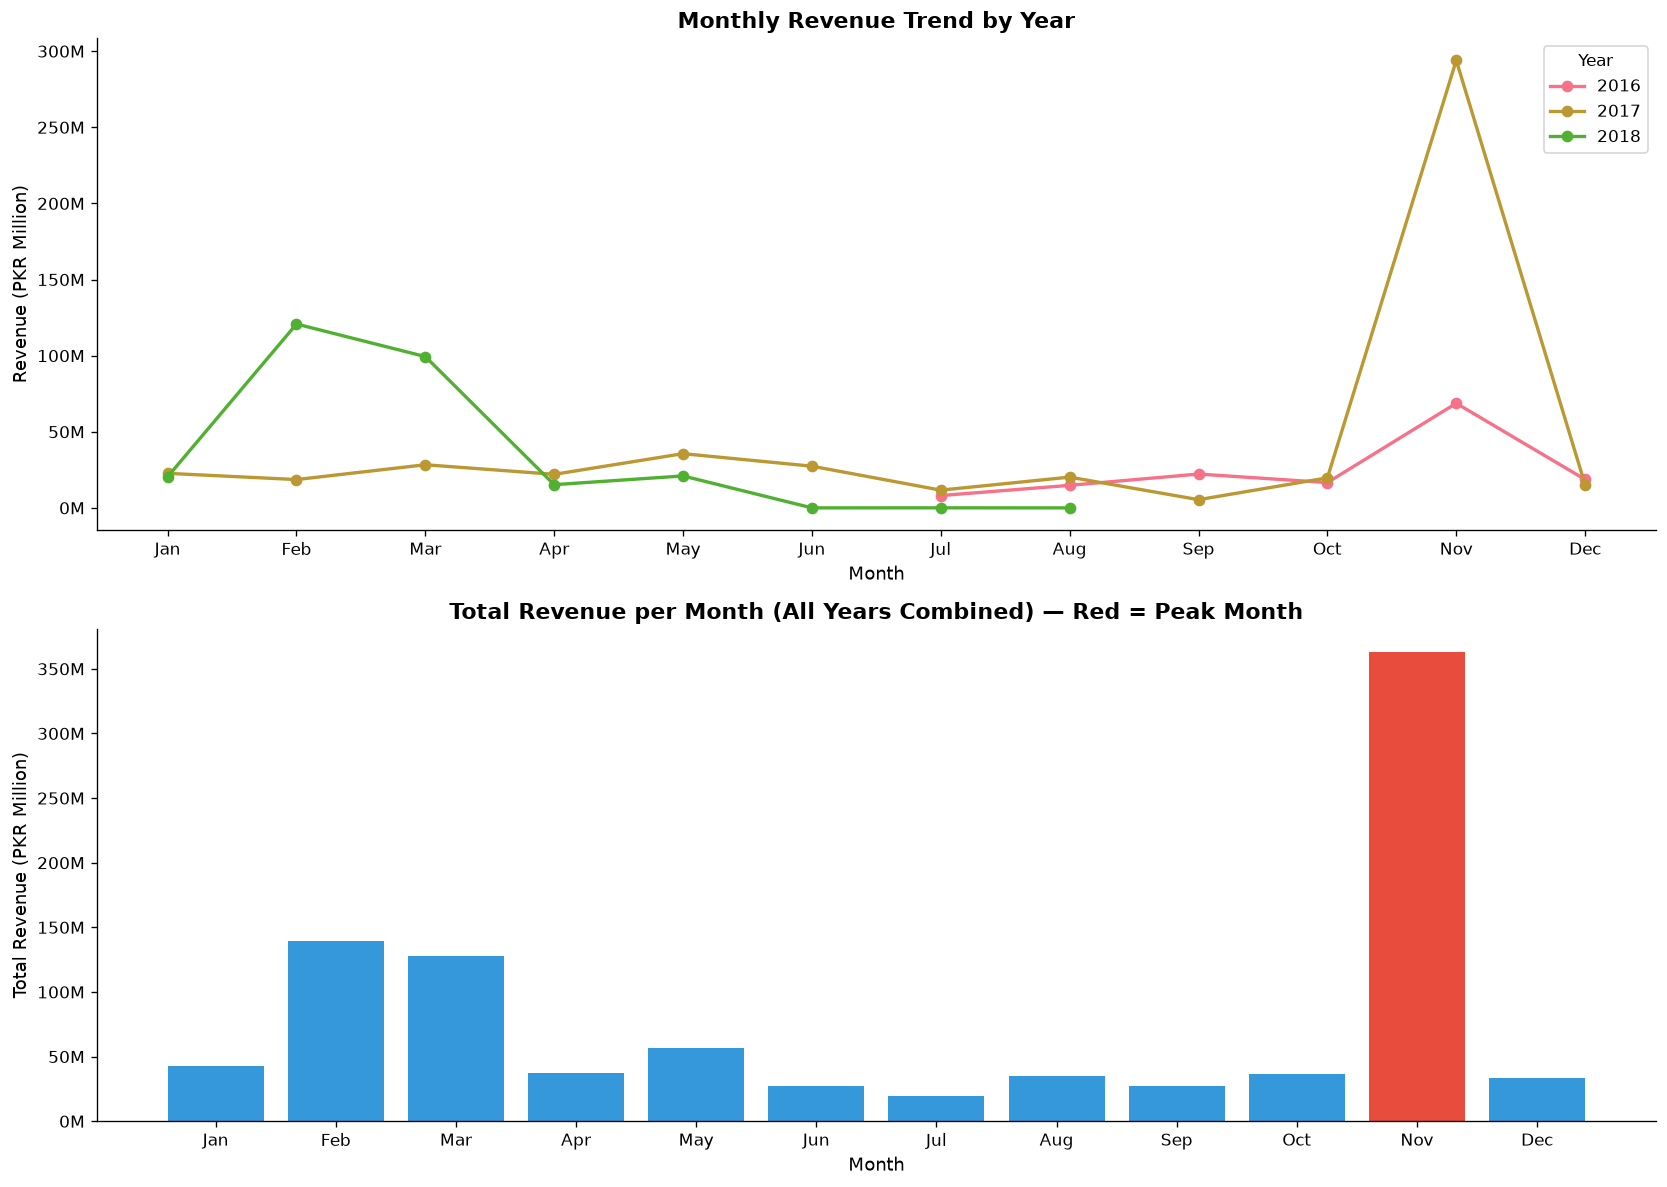

Peak month: Nov with PKR 362.7M


In [19]:
month_sales = (df_complete
               .groupby(['order_year', 'order_month'])['grand_total']
               .sum()
               .reset_index())

# Also compute total per month across all years
monthly_total = (df_complete
                 .groupby('order_month')['grand_total']
                 .sum()
                 .reset_index())
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_total['month_name'] = monthly_total['order_month'].apply(lambda x: month_names[int(x)-1])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Time-series line chart
for year in sorted(df_complete['order_year'].dropna().unique()):
    ys = month_sales[month_sales['order_year'] == year]
    ax1.plot(ys['order_month'], ys['grand_total'] / 1e6,
             marker='o', label=str(int(year)), linewidth=2)

ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Revenue (PKR Million)', fontsize=11)
ax1.set_title('Monthly Revenue Trend by Year', fontsize=13, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.legend(title='Year')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

# Bar chart — total per month
colors = ['#e74c3c' if v == monthly_total['grand_total'].max() else '#3498db'
          for v in monthly_total['grand_total']]
ax2.bar(monthly_total['month_name'], monthly_total['grand_total'] / 1e6, color=colors)
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Total Revenue (PKR Million)', fontsize=11)
ax2.set_title('Total Revenue per Month (All Years Combined) — Red = Peak Month',
              fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

plt.tight_layout()
plt.savefig('viz4_monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

peak = monthly_total.loc[monthly_total['grand_total'].idxmax()]
print(f"Peak month: {peak['month_name']} with PKR {peak['grand_total']/1e6:.1f}M")


### Q5 — Customer return rate

Total unique customers:    66,293
New customers (1 order):   44,060
Returning customers (2+):  22,233
Return rate:               33.5%


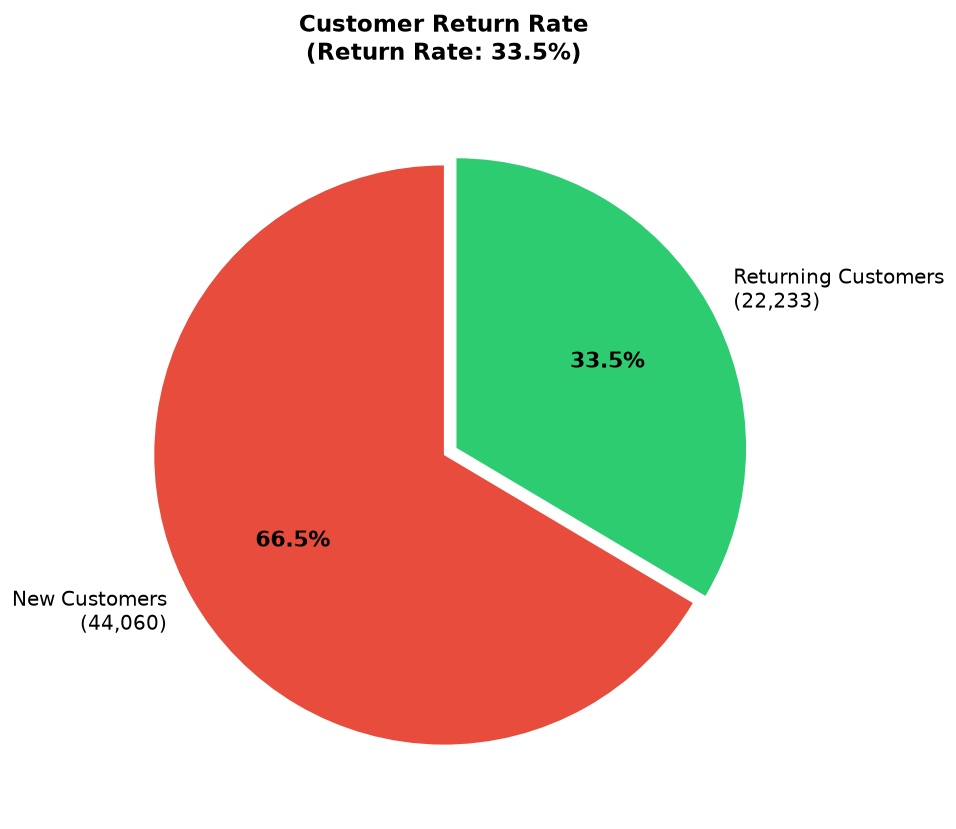

In [20]:
# A returning customer is one who appears in more than one completed order
customer_orders = (df_complete
                   .groupby('Customer ID')['increment_id']
                   .nunique())

new_customers      = (customer_orders == 1).sum()
returning_customers = (customer_orders > 1).sum()
total_customers    = len(customer_orders)
return_rate        = returning_customers / total_customers * 100

print(f"Total unique customers:    {total_customers:,}")
print(f"New customers (1 order):   {new_customers:,}")
print(f"Returning customers (2+):  {returning_customers:,}")
print(f"Return rate:               {return_rate:.1f}%")

# Pie chart
fig, ax = plt.subplots(figsize=(8, 8))
sizes  = [new_customers, returning_customers]
labels = [f'New Customers\n({new_customers:,})',
          f'Returning Customers\n({returning_customers:,})']
colors = ['#e74c3c', '#2ecc71']
explode = (0, 0.05)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, explode=explode, startangle=90,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

ax.set_title(f'Customer Return Rate\n(Return Rate: {return_rate:.1f}%)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz5_customer_return_rate.png', dpi=150, bbox_inches='tight')
plt.show()


### Q6 — Order value distribution (Box plot for outliers)

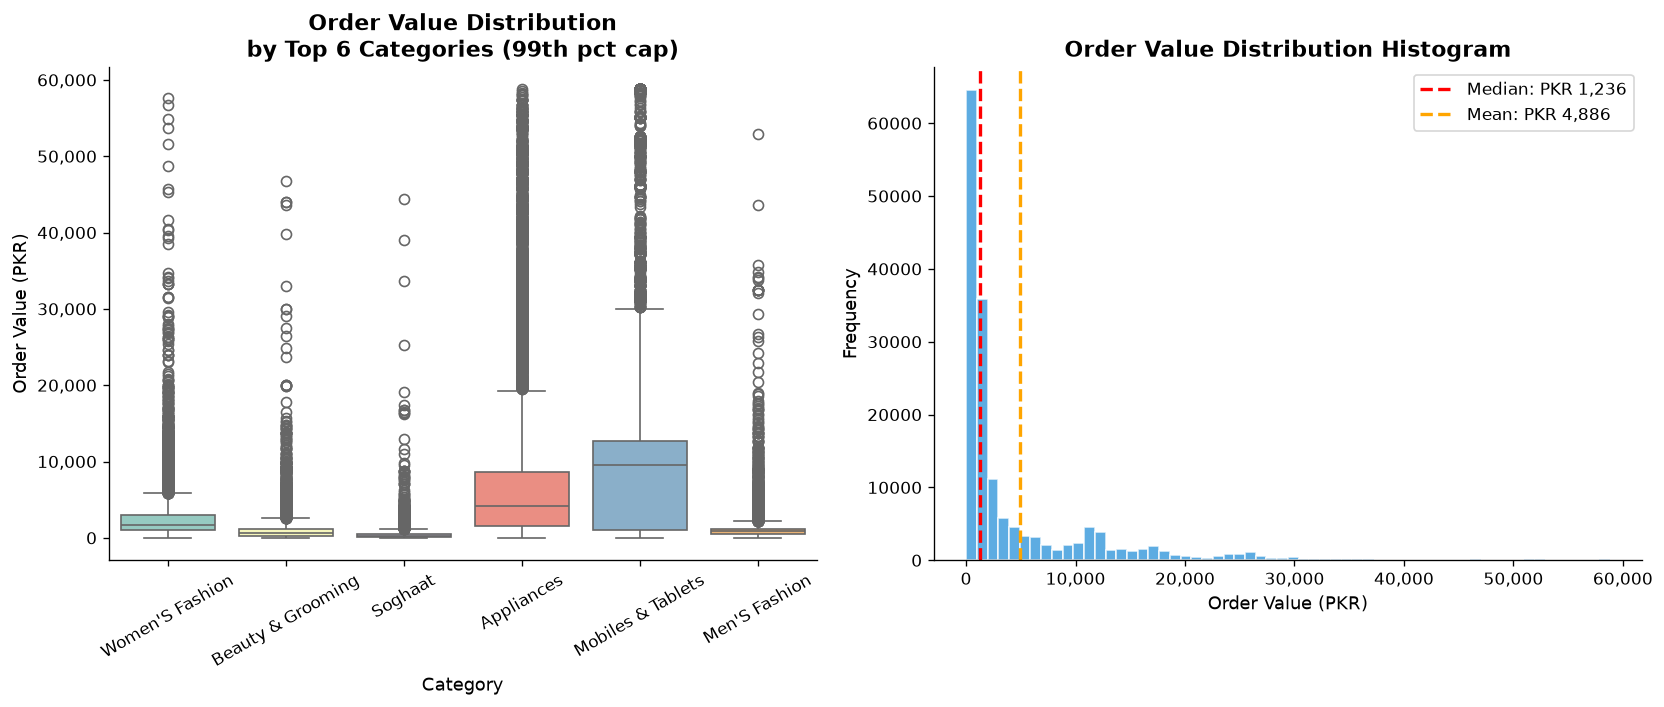

In [21]:
# Cap at 99th percentile to make the box plot readable
p99 = df_complete['grand_total'].quantile(0.99)
df_box = df_complete[df_complete['grand_total'] <= p99].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Box plot by top 6 categories
top6 = df_complete['category_name_1'].value_counts().head(6).index
df_top6 = df_box[df_box['category_name_1'].isin(top6)]

sns.boxplot(data=df_top6, x='category_name_1', y='grand_total',
            palette='Set3', ax=ax1)
ax1.set_xlabel('Category', fontsize=11)
ax1.set_ylabel('Order Value (PKR)', fontsize=11)
ax1.set_title('Order Value Distribution\nby Top 6 Categories (99th pct cap)',
              fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', rotation=30)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Overall distribution histogram
ax2.hist(df_box['grand_total'], bins=60, color='#3498db', edgecolor='white', alpha=0.8)
ax2.axvline(df_box['grand_total'].median(), color='red', linestyle='--',
            linewidth=2, label=f"Median: PKR {int(df_box['grand_total'].median()):,}")
ax2.axvline(df_box['grand_total'].mean(), color='orange', linestyle='--',
            linewidth=2, label=f"Mean: PKR {int(df_box['grand_total'].mean()):,}")
ax2.set_xlabel('Order Value (PKR)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Order Value Distribution Histogram',
              fontsize=13, fontweight='bold')
ax2.legend()
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('viz6_order_value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Visualization 7 — Order status breakdown

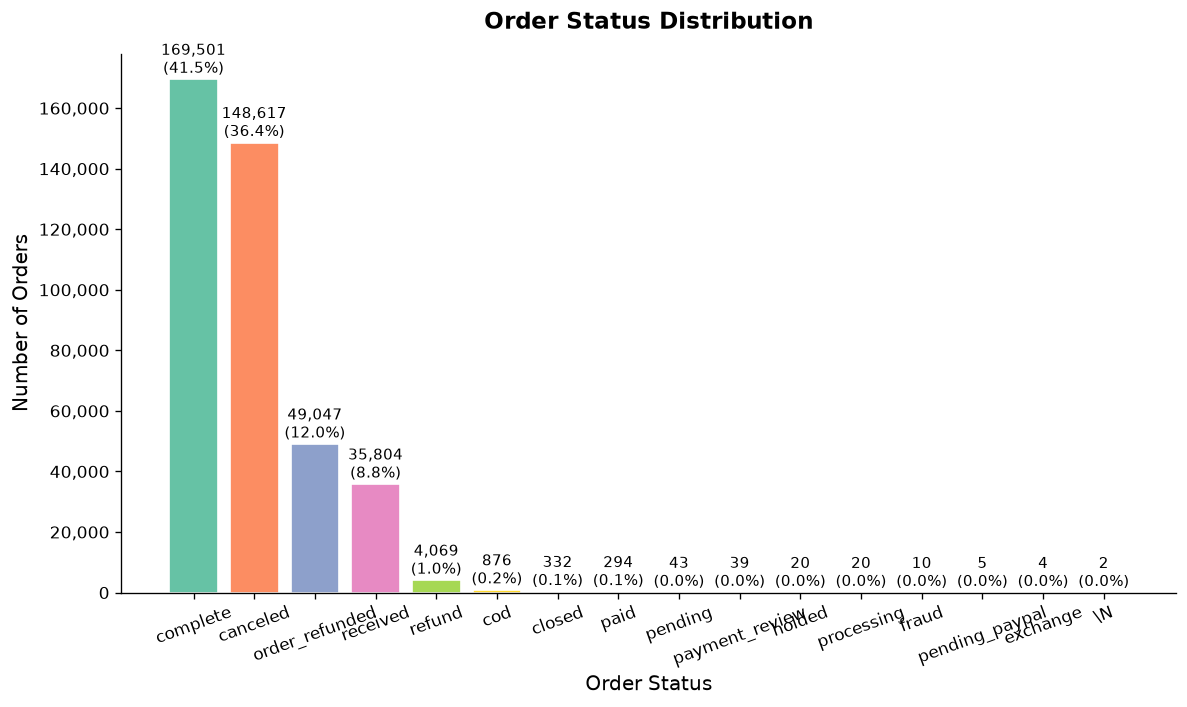

In [22]:
status_counts = df['status'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Set2', len(status_counts))
bars = ax.bar(status_counts.index, status_counts.values, color=colors, edgecolor='white')

ax.set_xlabel('Order Status', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Order Status Distribution', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar in bars:
    pct = bar.get_height() / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('viz7_order_status.png', dpi=150, bbox_inches='tight')
plt.show()


### Visualization 8 — Correlation heatmap

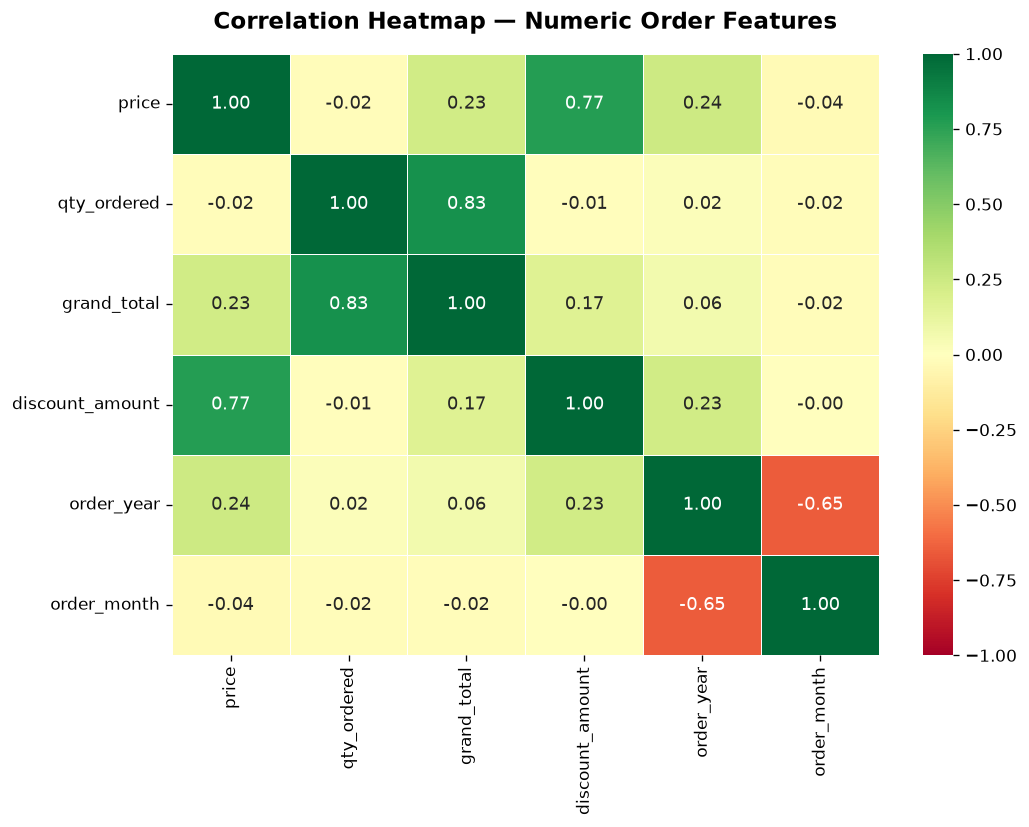


Key correlations with grand_total:
grand_total        1.000000
qty_ordered        0.826899
price              0.229863
discount_amount    0.167853
order_year         0.062785
order_month       -0.019011
Name: grand_total, dtype: float64


In [23]:
# Select numeric columns for correlation analysis
num_cols = ['price', 'qty_ordered', 'grand_total', 'discount_amount',
            'order_year', 'order_month']
corr_df = df_complete[num_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 11}, ax=ax)

ax.set_title('Correlation Heatmap — Numeric Order Features',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz8_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey correlations with grand_total:")
print(corr_matrix['grand_total'].sort_values(ascending=False))


### Visualization 9 — Payment method market share

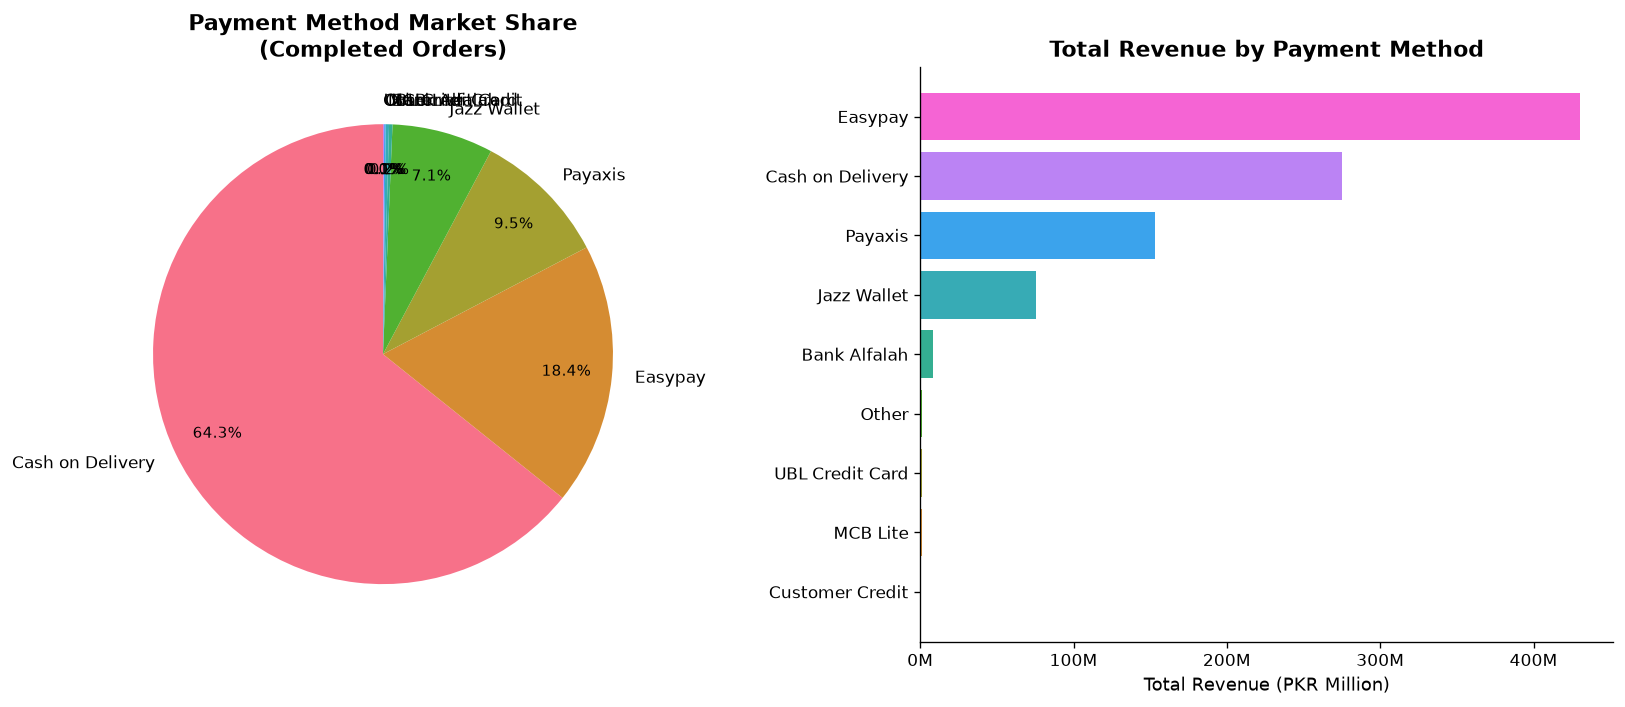

In [24]:
pay_counts = df_complete['payment_clean'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
wedges, texts, autotexts = ax1.pie(
    pay_counts.values, labels=pay_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('husl', len(pay_counts)),
    pctdistance=0.8
)
for at in autotexts:
    at.set_fontsize(9)
ax1.set_title('Payment Method Market Share\n(Completed Orders)',
              fontsize=13, fontweight='bold')

# Revenue by payment method
pay_revenue = (df_complete.groupby('payment_clean')['grand_total']
               .sum().sort_values(ascending=True))
ax2.barh(pay_revenue.index, pay_revenue.values / 1e6,
         color=sns.color_palette('husl', len(pay_revenue)))
ax2.set_xlabel('Total Revenue (PKR Million)', fontsize=11)
ax2.set_title('Total Revenue by Payment Method',
              fontsize=13, fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

plt.tight_layout()
plt.savefig('viz9_payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Business Insights Summary

### Top 5 Business Insights from Pakistan E-Commerce Data Analysis

---

**Insight 1: Mobiles & Tablets Dominate Revenue — But Margins May Be Thin**

Mobiles & Tablets is the single largest revenue-generating category, accounting for a disproportionate share of total sales. However, the high order volumes combined with aggressive discounting in this category suggest that while topline revenue is strong, profitability may be pressured. The business should investigate whether this category drives sustainable margins or is primarily fuelled by discount-driven demand. Diversifying into higher-margin categories like Appliances or Women's Fashion — which show strong revenue with lower discount rates — could improve overall profitability.

---

**Insight 2: Cash on Delivery (COD) Dominates But Carries Risk**

Over 46% of all completed orders are paid via Cash on Delivery, making it by far the most popular payment method in Pakistan. While this reflects consumer trust issues with digital payments, COD orders carry significant operational risk — higher return rates, failed deliveries, and cash handling costs. The data shows that digital payment methods (Easypay, Jazz Wallet) have grown substantially, suggesting an opportunity to incentivise digital payments through small discounts or loyalty points, which would reduce COD-related losses.

---

**Insight 3: November is the Peak Sales Month — Seasonal Surge Opportunity**

November consistently records the highest sales across all years in the dataset, likely driven by end-of-year sales campaigns similar to Black Friday and 11.11 sales popular in global e-commerce. This peak is significantly higher than any other month, suggesting that inventory planning, logistics capacity, and marketing budgets should be heavily front-loaded into October–November. The business is leaving money on the table if it doesn't aggressively prepare for this window with targeted promotions and sufficient stock.

---

**Insight 4: Low Customer Return Rate Signals Retention Problem**

The analysis reveals that the majority of customers place only one order, indicating a very low repeat purchase rate. In e-commerce, customer acquisition costs are high — retaining existing customers is 5–7x cheaper than acquiring new ones. The business should invest in post-purchase engagement: loyalty programs, personalised email campaigns, and re-targeting ads. Even increasing the return rate by 5–10 percentage points could significantly improve lifetime customer value and reduce dependence on costly new customer acquisition.

---

**Insight 5: Order Cancellation Rate is Alarmingly High**

A significant proportion of orders have a 'canceled' status — nearly matching the number of completed orders in some periods. High cancellation rates indicate friction in the customer journey: whether from payment failures, out-of-stock items, or delivery issues. This represents a direct revenue loss that is preventable. The business should analyse cancellation reasons at the category level, improve payment gateway reliability (reducing failed transactions), and implement real-time inventory management to avoid accepting orders for unavailable items.

---

*Analysis conducted on Pakistan's Largest E-Commerce Dataset (Kaggle) covering 2016–2018. All monetary values are in Pakistani Rupees (PKR).*


## 6. Final Summary Statistics

In [25]:
print("=" * 55)
print("  PAKISTAN E-COMMERCE DATASET — FINAL SUMMARY")
print("=" * 55)
print(f"  Total raw rows:            {len(df_raw):>12,}")
print(f"  Cleaned rows:              {len(df):>12,}")
print(f"  Completed orders:          {len(df_complete):>12,}")
print(f"  Total revenue (completed): PKR {df_complete['grand_total'].sum():>10,.0f}")
print(f"  Average order value:       PKR {df_complete['grand_total'].mean():>10,.0f}")
print(f"  Median order value:        PKR {df_complete['grand_total'].median():>10,.0f}")
print(f"  Unique customers:          {df_complete['Customer ID'].nunique():>12,}")
print(f"  Unique categories:         {df_complete['category_name_1'].nunique():>12,}")
print(f"  Date range:                {df_complete['created_at'].min().date()} to "
      f"{df_complete['created_at'].max().date()}")
print("=" * 55)


  PAKISTAN E-COMMERCE DATASET — FINAL SUMMARY
  Total raw rows:               1,048,575
  Cleaned rows:                   408,683
  Completed orders:               165,826
  Total revenue (completed): PKR 946,876,366
  Average order value:       PKR      5,710
  Median order value:        PKR      1,255
  Unique customers:                66,293
  Unique categories:                   16
  Date range:                2016-07-01 to 2018-08-12
